In [ ]:
!pip install gTTS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.6 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.0 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt


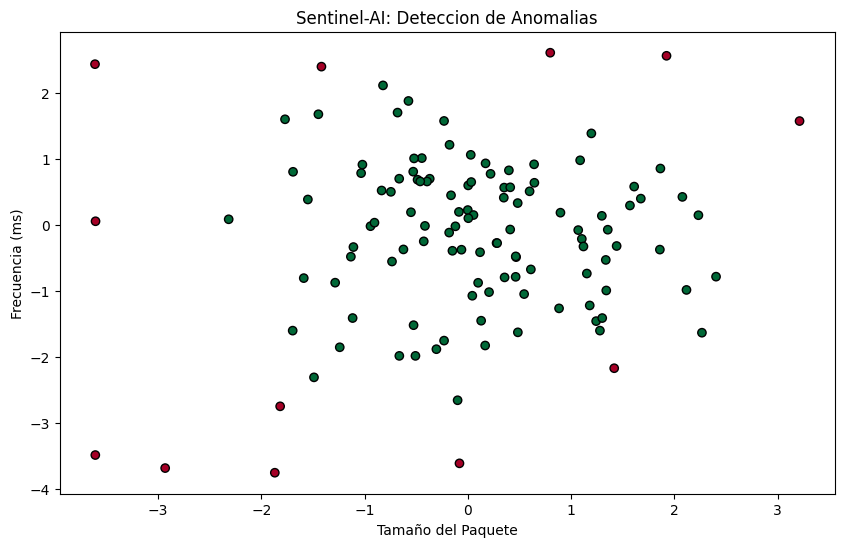

Puntos rojos= Ataques detectados
Puntos verdes= Trafico normal


In [ ]:
normal = np.random.normal(size=(100,2), loc=0)
ataque = np.random.uniform(low=-4, high=4, size=(20,2))
X = np.r_[normal, ataque]
clf = IsolationForest(contamination=0.1, random_state=42)
preds = clf.fit_predict(X)
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=preds, cmap='RdYlGn', edgecolors='k')
plt.title("Sentinel-AI: Deteccion de Anomalias")
plt.xlabel("Tamaño del Paquete")
plt.ylabel("Frecuencia (ms)")
plt.show()
print("Puntos rojos= Ataques detectados")
print("Puntos verdes= Trafico normal")








In [ ]:
conexiones_nuevas = np.random.uniform(low=-5, high=5, size=(10,2))
decisiones = clf.predict(conexiones_nuevas)
print("--- ESCANEO DE SEGURIDAD EN TIEMPO REAL ---")
for i in range(len(conexiones_nuevas)):
  if decisiones[i] == -1:
    print("f CONEXION {i+1}: BLOQUEADA (Anomalia detectada)")
  else:
      print(f"CONEXION {i+1}: PERMITIDA")

--- ESCANEO DE SEGURIDAD EN TIEMPO REAL ---
f CONEXION {i+1}: BLOQUEADA (Anomalia detectada)
f CONEXION {i+1}: BLOQUEADA (Anomalia detectada)
f CONEXION {i+1}: BLOQUEADA (Anomalia detectada)
f CONEXION {i+1}: BLOQUEADA (Anomalia detectada)
f CONEXION {i+1}: BLOQUEADA (Anomalia detectada)
f CONEXION {i+1}: BLOQUEADA (Anomalia detectada)
f CONEXION {i+1}: BLOQUEADA (Anomalia detectada)
f CONEXION {i+1}: BLOQUEADA (Anomalia detectada)
f CONEXION {i+1}: BLOQUEADA (Anomalia detectada)
f CONEXION {i+1}: BLOQUEADA (Anomalia detectada)


In [ ]:
datos_limpios = conexiones_nuevas[decisiones == 1]
print (f"Datos originales: {len(conexiones_nuevas)}")
print (f"Datos tras la limpieza: {len(datos_limpios)}")
print ("El sistema ha purgado las amenazas automaticamente")

Datos originales: 10
Datos tras la limpieza: 0
El sistema ha purgado las amenazas automaticamente


In [ ]:
import joblib
joblib.dump(clf, 'modelo_centinela_v1.pkl')
print("PROYECTO COMPLETADO! El archivo 'modelo_centinela_v1.pkl'ha sido creado.")
print("Este archivo es tu IA. Puedes llevarla en una USB y funcionara donde sea.")

PROYECTO COMPLETADO! El archivo 'modelo_centinela_v1.pkl'ha sido creado.
Este archivo es tu IA. Puedes llevarla en una USB y funcionara donde sea.


In [ ]:
import pandas as pd
datos_ejemplo = {
    'tamaño_paquete': [0.12, 0.15, 5.5, 0.11, 4.8, 0.13, 0.14],
    'frecuencia': [10, 12, 500, 11, 480, 13, 11],
    'ip_origen': ['192.168.1.1', '192.168.1.5','10.0.0.99', '192.168.1.3', '10.0.0.98', '192.168.1.4', '192.168.1.10']
}
df= pd.DataFrame(datos_ejemplo)
print("TABLA CARGADA! Estructura perfecta de 7x3.")
print(df)

TABLA CARGADA! Estructura perfecta de 7x3.
   tamaño_paquete  frecuencia     ip_origen
0            0.12          10   192.168.1.1
1            0.15          12   192.168.1.5
2            5.50         500     10.0.0.99
3            0.11          11   192.168.1.3
4            4.80         480     10.0.0.98
5            0.13          13   192.168.1.4
6            0.14          11  192.168.1.10


In [ ]:
X_analizar = df[['tamaño_paquete', 'frecuencia']]
predicciones = clf.predict(X_analizar)
df['veredicto'] = predicciones
df['accion_tomada']= df['veredicto'].apply(lambda x: 'BLOQUEAR' if x == -1 else 'PERMITIR')
print("MONITOR DE SEGURIDAD ACTIVO ---")
print(df[['ip_origen', 'tamaño_paquete', 'accion_tomada']])


MONITOR DE SEGURIDAD ACTIVO ---
      ip_origen  tamaño_paquete accion_tomada
0   192.168.1.1            0.12      BLOQUEAR
1   192.168.1.5            0.15      BLOQUEAR
2     10.0.0.99            5.50      BLOQUEAR
3   192.168.1.3            0.11      BLOQUEAR
4     10.0.0.98            4.80      BLOQUEAR
5   192.168.1.4            0.13      BLOQUEAR
6  192.168.1.10            0.14      BLOQUEAR


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


In [ ]:
from sklearn.ensemble import IsolationForest
clf_ajustado = IsolationForest(contamination=0.05, random_state=42)
clf_ajustado.fit(X)
df['nuevo_veredicto'] = clf_ajustado.predict(df[['tamaño_paquete', 'frecuencia']])
print("---COMPARATIVA DE SENSIBILIDAD---")
print(df[['ip_origen', 'veredicto', 'nuevo_veredicto']])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


---COMPARATIVA DE SENSIBILIDAD---
      ip_origen  veredicto  nuevo_veredicto
0   192.168.1.1         -1                1
1   192.168.1.5         -1                1
2     10.0.0.99         -1               -1
3   192.168.1.3         -1                1
4     10.0.0.98         -1               -1
5   192.168.1.4         -1                1
6  192.168.1.10         -1                1


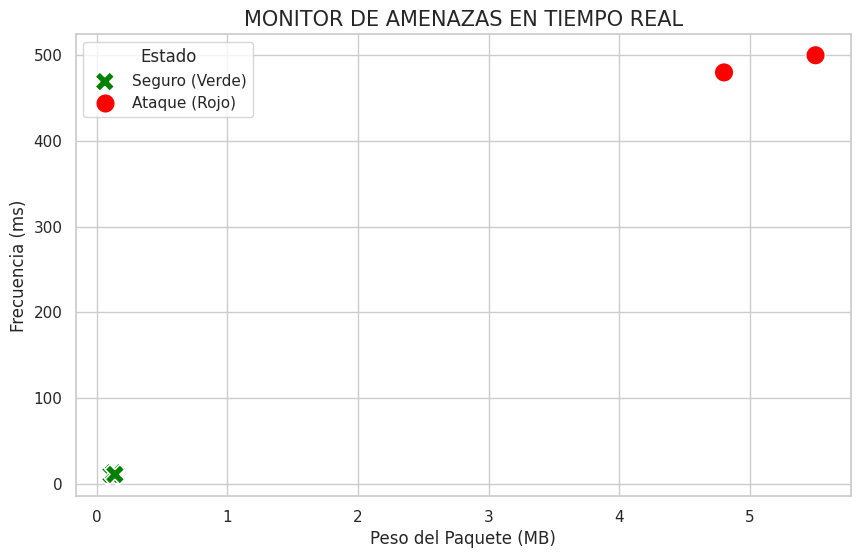

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
grafica = sns.scatterplot(
    data=df,
    x='tamaño_paquete',
    y='frecuencia',
    hue='nuevo_veredicto',
    palette={1: 'green', -1: 'red'},
    s=200,
    style='nuevo_veredicto'
)
plt.title("MONITOR DE AMENAZAS EN TIEMPO REAL", fontsize=15)
plt.xlabel("Peso del Paquete (MB)")
plt.ylabel("Frecuencia (ms)")
plt.legend(title='Estado', labels=['Seguro (Verde)', 'Ataque (Rojo)'])
plt.show()

In [ ]:
!pip install gTTS

In [ ]:
from gtts import gTTS
from IPython.display import Audio
peor_ataque = df[df['nuevo_veredicto'] == -1].iloc[0]
ip= peor_ataque['ip_origen']
peso = peor_ataque['tamaño_paquete']
texto_alerta = f"Alerta de seguridad jefe. He bloqueado la direccion I P {ip} porque envio un paquete de {peso} megabytes. El sistema esta protegido."
tts= gTTS(texto_alerta, lang='es')
tts.save('alerta.mp3')
print("Alerta generada. Dale play al reproductor de abajo:")
Audio('alerta.mp3', autoplay=True)

Alerta generada. Dale play al reproductor de abajo:


In [ ]:
def asistente_seguridad(ip_sospechosa, magnitud):
  saludo = "Hola Jefe, "
  analisis = f"se ha detectado que la direccion {ip_sospechosa} esta enviando paquetes de {magnitud} megas."
  if magnitud > 5:
    veredicto = "Esto es claramente un ataque de denegacion de servicio, Ya procedi a banear la IP permanentemente."
  else:
    veredicto = "Es un comportamiento extraño, pero lo mantendre bajo vigilancia por si acaso."

  mensaje_completo = saludo + analisis + veredicto
  tts = gTTS(mensaje_completo, lang='es')
  tts.save('respuesta_ia.mp3')
  return Audio('respuesta_ia.mp3', autoplay=True)
asistente_seguridad("10 punto 0 punto 0 punto 99", 2.0)

In [ ]:
!pip install SpeechRecognition

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 21.9 MB/s eta 0:00:00


In [ ]:
from IPython.display import HTML
aura_html = """
<div id="aura-container" style="display: flex; justify-content: center; align-items: center; height 200px;">
<div class"aura"></div>
</div>
<style>
.aura {
  witdth: 100px;
  heigth: 100px;
  border-radius: 50%;
  background-color: radial-gradient(circle, #00f2ff 0%, #0062ff 70%);
  box-shadow: 0 0 20px #00f2ff, 0 0 60px #0062ff;
  animation: pulse 2s infinite;
}
@keyframes pulse {
  0% { transform: scale(1); opacity: 0.8; }
  50% { transform: scale(1.2); opacity: 1; box-shadow: 0 0 40px #00f2ff, 0 0 100px #0062ff; }
  100% { transform: scale(1); opacity: 0.8; }
}
</style>
"""
display(HTML(aura_html))
print("SISTEMA VISUAL ONLINE")

SISTEMA VISUAL ONLINE


In [ ]:
from IPython.display import display, Javascript
from google.colab import output
import base64
def escuchar_voz():
  js = Javascript('''
  async function recordAudio() {
    const div = document.createElement('div');
    const button = document.createElement('button');
    button.textContent = 'HABLAR AHORA';
    button.style.background = '#00f2ff';
    button.style.padding = '10px';
    button.style.borderRadius = '5px';
    document.body.appendChild(div);
    div.appendChild(button);

    const stream = await navigator.mediaDevices.getUserMedia({ audio: true });
    const options = { mimeType: 'audio/webm' }; // Changed to webm
    const recorder = new MediaRecorder(stream, options);
    const audioChunks = [];

    let recording = false;
    button.onclick = () => {
      if (!recording) {
        recorder.start();
        button.textContent = 'ESCUCHANDO... (Click para parar)';
        button.style.background = '#ff4b4b';
        recording = true;
      } else {
        recorder.stop();
        button.textContent = 'HABLAR AHORA';
        button.style.background = '#00f2ff';
        recording = false;
      }
    };

    const promise = new Promise((resolve) => {
      recorder.onstop = () => {
        const blob = new Blob(audioChunks, { type: 'audio/webm' }); // Changed to webm
        const reader = new FileReader();
        reader.readAsDataURL(blob);
        reader.onloadend = () => {
          resolve(reader.result.split(',')[1]);
        };
      };
    });
    recorder.ondataavailable = (e) => audioChunks.push(e.data);
    return promise;
  }
  ''')
  display(js)
  data = output.eval_js('recordAudio()')
  binary = base64.b64decode(data)
  with open('audio_usuario.webm', 'wb') as f: # Changed filename to webm
    f.write(binary)
#ejecutar el oido
escuchar_voz()

<IPython.core.display.Javascript object>

In [ ]:
import speech_recognition as sr
# We'll need to install pydub to convert webm to wav for speech_recognition
!pip install pydub
from pydub import AudioSegment

r = sr.Recognizer()

# Convert webm to wav before processing with speech_recognition
AudioSegment.from_file('audio_usuario.webm').export('audio_usuario.wav', format='wav')

with sr.AudioFile('audio_usuario.wav') as source:
  audio = r.record(source)
  try:
    texto_dicho = r.recognize_google(audio, language='es-ES')
    print(f"Escuche que dijiste: '{texto_dicho}'")
    if "reporte" in texto_dicho.lower():
      print("Generando  reporte de voz...")
      peor_ataque = df[df['nuevo_veredicto'] == -1].iloc[0]
      display(asistente_seguridad(peor_ataque['ip_origen'], peor_ataque['tamaño_paquete']))
    else:
      print("Te escuche, pero no entendi el comando 'reporte'.")
  except Exception as e:
    print(f"No pude entender el audio. Podes intentar hablar mas claro? Error: {e}")

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


No pude entender el audio. Podes intentar hablar mas claro? Error: 


In [ ]:
from IPython.display import HTML, display, Audio
from gtts import gTTS

def respuesta_con_estilo(ip, magnitud, es_ataque):
  color_aura = "#00f2ff" if not es_ataque else "#ff0044"
  sombra_aura = "#0062ff" if not es_ataque else "#880000"
  titulo = "SISTEMA SEGURO" if not es_ataque else "ALERTA DE INTRUSION"
  mensaje = (f"Jefe, reporte de seguridad. La IP {ip} mostró un flujo de {magnitud} megas."
  f"{'He bloqueado la amenaza de inmediato.' if es_ataque else 'El tráfico es normal, sigo monitoreando.'}")
  tts = gTTS(mensaje, lang='es')
  tts.save('respuesta.mp3')

  html_code = f"""
  <div style="background-color: #0e1117; padding: 30px; border-radius: 20px; text-align: center; border: 2px solid {color_aura};">
  <div class="aura"></div>
  <p style="color: white; font-family: sans-serif; margin-top: 20px;">IP ORIGEN: {ip}</p>
  </div>
  <style>
  .aura {{
    width: 120px;
    height: 120px;
    margin: 0 auto;
    background: radial-gradient(circle, {color_aura} 0%, {sombra_aura} 70%);
    border-radius: 50%;
    box-shadow: 0 0 40px {color_aura};
    animation: pulse 1.5s infinite ease-in-out;
    }}
    @keyframes pulse {{
      0% {{ transform: scale(1); opacity: 0.8; }}
      50% {{ transform: scale(1.15); opacity: 1; box-shadow: 0 0 70px {color_aura}; }}
      100% {{ transform: scale(1); opacity: 0.8; }}
    }}
    </style>
    """
  display(HTML(html_code))
  return Audio('respuesta.mp3', autoplay=True)

print("Modulo de Visualizacion Cargado")

Modulo de Visualizacion Cargado


In [ ]:
print("---PROBANDO ESCENARIO SEGURO---")
display(respuesta_con_estilo("192.168.1.15", 0.5, es_ataque=False))
print("---PROBANDO ESCENARIO DE ALERTA---")
display(respuesta_con_estilo("10.0.0.666", 25.8, es_ataque=True))

---PROBANDO ESCENARIO SEGURO---


---PROBANDO ESCENARIO DE ALERTA---


In [ ]:
import time
def ejecutar_monitoreo_final(dataset):
  print("DEBUG: Entre a la funcion...")
  print("INICIANDO ESCANEO DE SEGURIDAD IA..")
  time.sleep(1)
  ataques = dataset[dataset['nuevo_veredicto'] == -1]
  if not ataques.empty:
    peor_ataque = ataques.sort_values(by='tamaño_paquete', ascending=False).iloc[0]
    display(respuesta_con_estilo(
        peor_ataque['ip_origen'],
        peor_ataque['tamaño_paquete'],
        es_ataque=True
    ))
  else:
    display(respuesta_con_estilo("Red Limpia", 0, es_ataque=False))


In [ ]:
if 'df' in locals():
  print("Iniciando el escaneo final del sistema...")
  ejecutar_monitoreo_final(df)
else:
  print(" Mae, el 'df' no esta cargado. Corre la celda donde generamos los datos primero.")

Iniciando el escaneo final del sistema...
DEBUG: Entre a la funcion...
INICIANDO ESCANEO DE SEGURIDAD IA..


In [ ]:
import joblib
try:
  joblib.dump(clf, 'centinela_ia.pkt')
  print("Archivo creado con exito")
except NameError:
  print("Primero tiene que darle 'Play' a todas las celdas de arriba para que la IA exista")

Archivo creado con exito
